<a href="https://colab.research.google.com/github/kxrrym03/Data-Center-AI-Water-Electricity-Usage/blob/main/Water_Electricity_Usage_in_Data_Centers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_center_hybrid.csv to data_center_hybrid.csv


In [3]:
df = pd.read_csv('data_center_hybrid.csv')
df.shape

(126770, 14)

In [4]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [5]:
df.tail()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
126765,2021,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,14.51,1.495,Evaporative,2.305,381.65,155454.82,High
126766,2022,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,14.77,1.485,Evaporative,2.281,378.59,153627.09,High
126767,2023,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.04,1.473,Evaporative,2.245,319.36,128626.89,High
126768,2024,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.31,1.450,Evaporative,2.231,394.69,160407.53,High
126769,2025,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.58,1.431,Evaporative,2.217,463.45,189650.23,High


In [6]:
df.isnull().sum()

,0
Year,0
Facility_ID,0
Facility_Name,0
Owner_Company,0
City,0
Country,0
Facility_Type,0
Estimated_Capacity_MW,0
PUE,0
Cooling_System_Type,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   Facility_Name                  126770 non-null  object 
 3   Owner_Company                  126770 non-null  object 
 4   City                           126770 non-null  object 
 5   Country                        126770 non-null  object 
 6   Facility_Type                  126770 non-null  object 
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  object 
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons     

In [10]:
df.dtypes

,0
Year,int64
Facility_ID,object
Facility_Name,object
Owner_Company,object
City,object
Country,object
Facility_Type,object
Estimated_Capacity_MW,float64
PUE,float64
Cooling_System_Type,object


### Data Visualization

### Distribution of Numerical Features

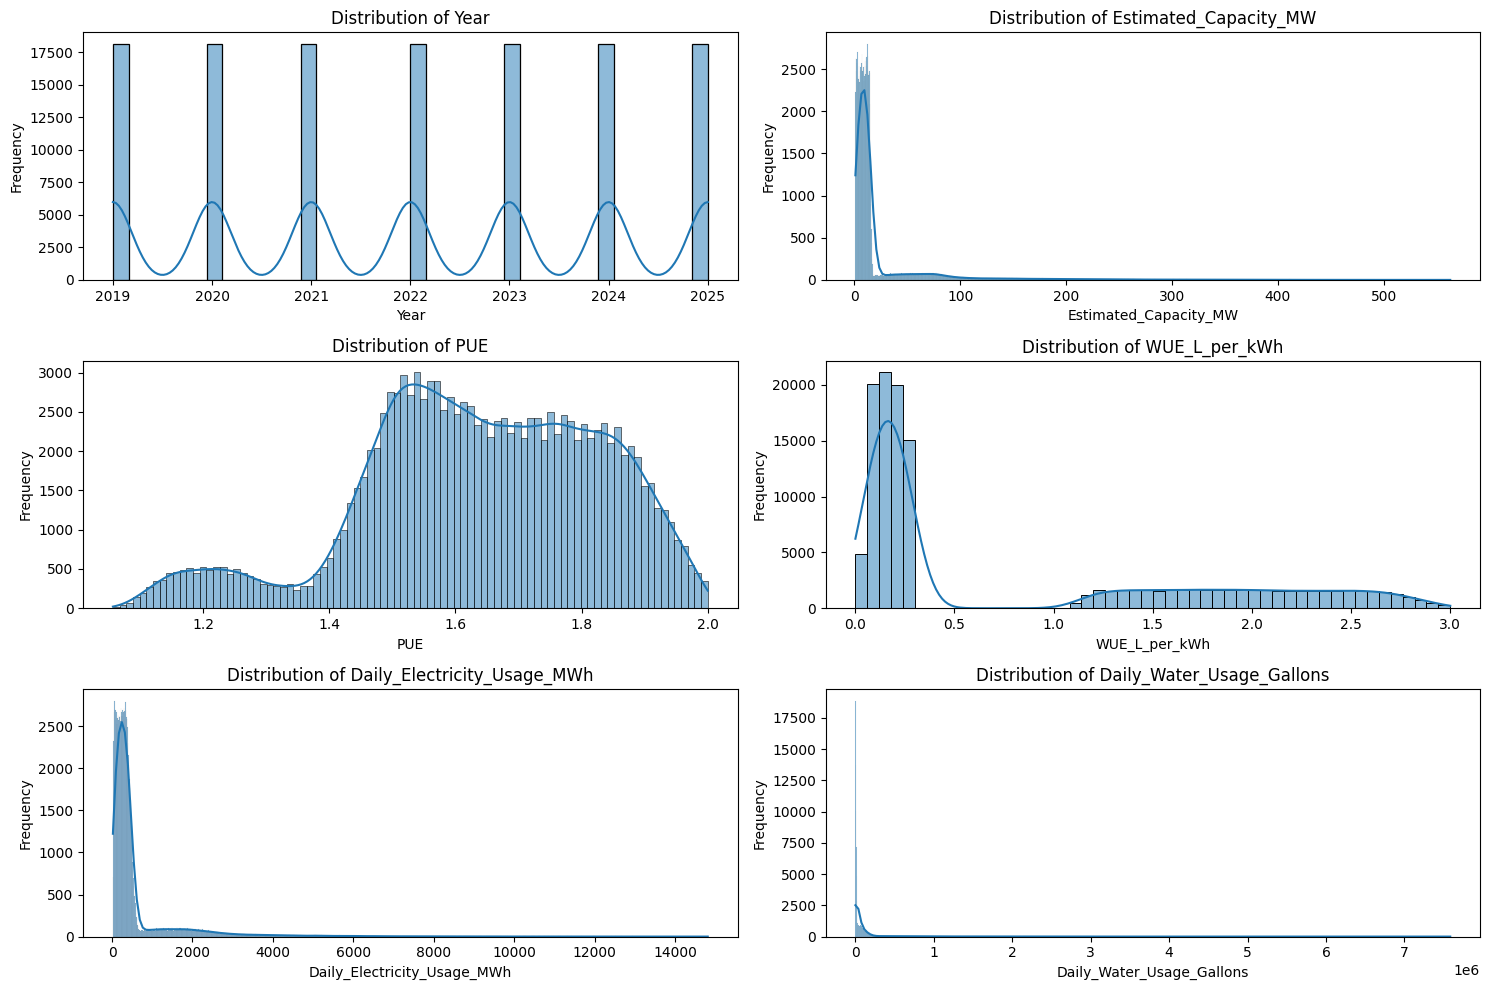

In [12]:
numerical_cols = ['Year', 'Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

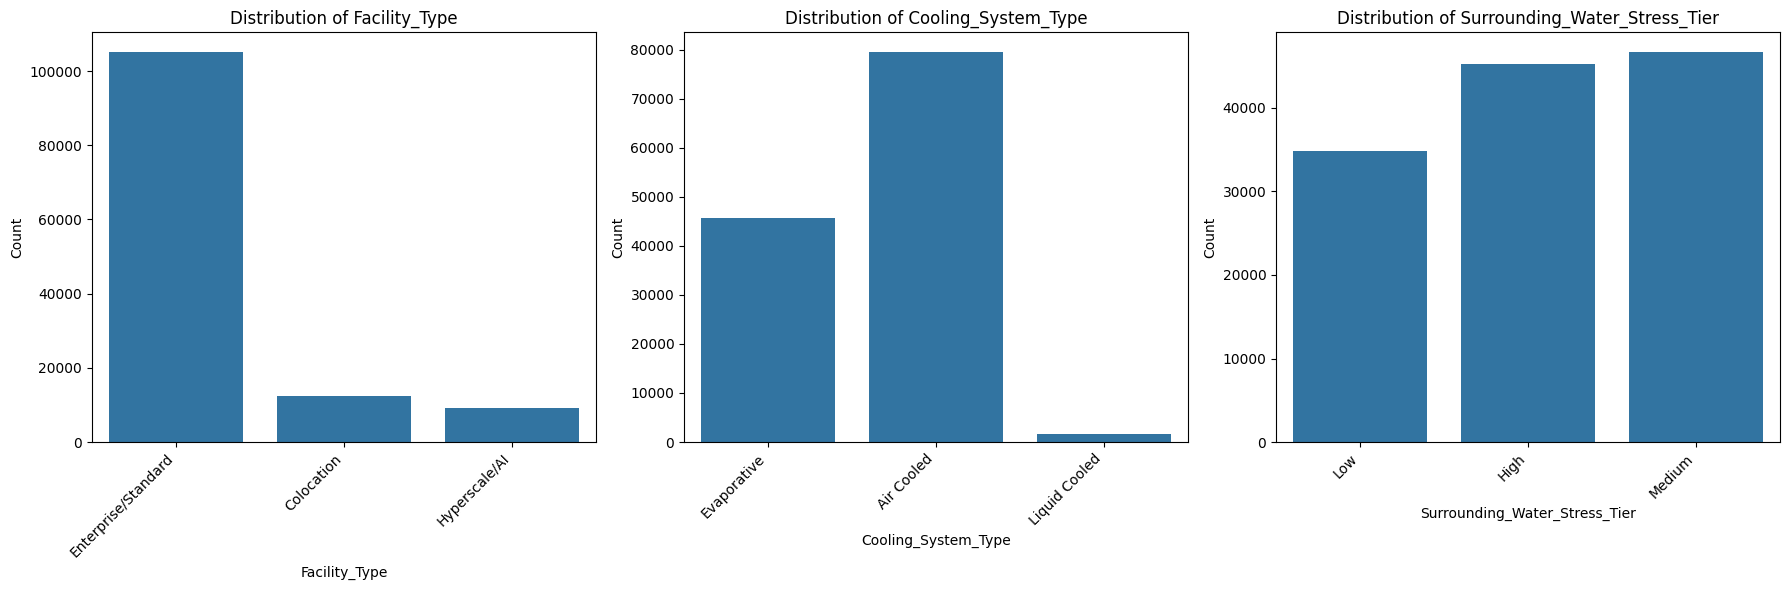

In [13]:
categorical_cols = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

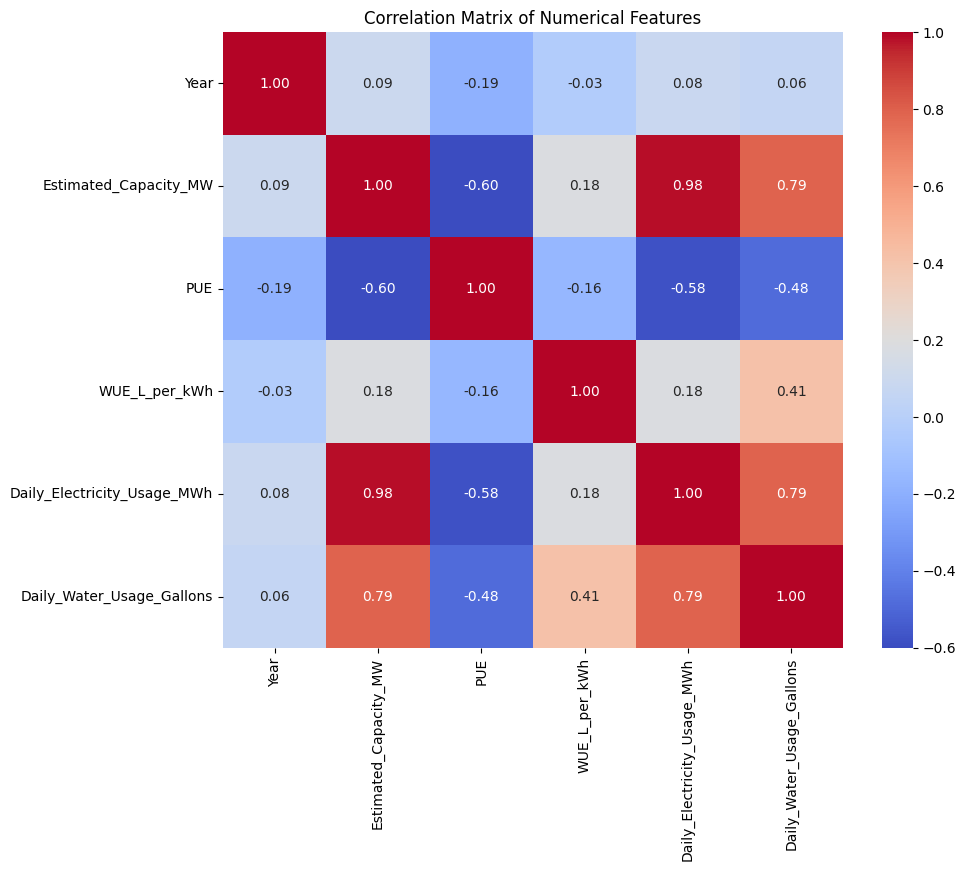

In [14]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Relationship between Categorical and Numerical Features

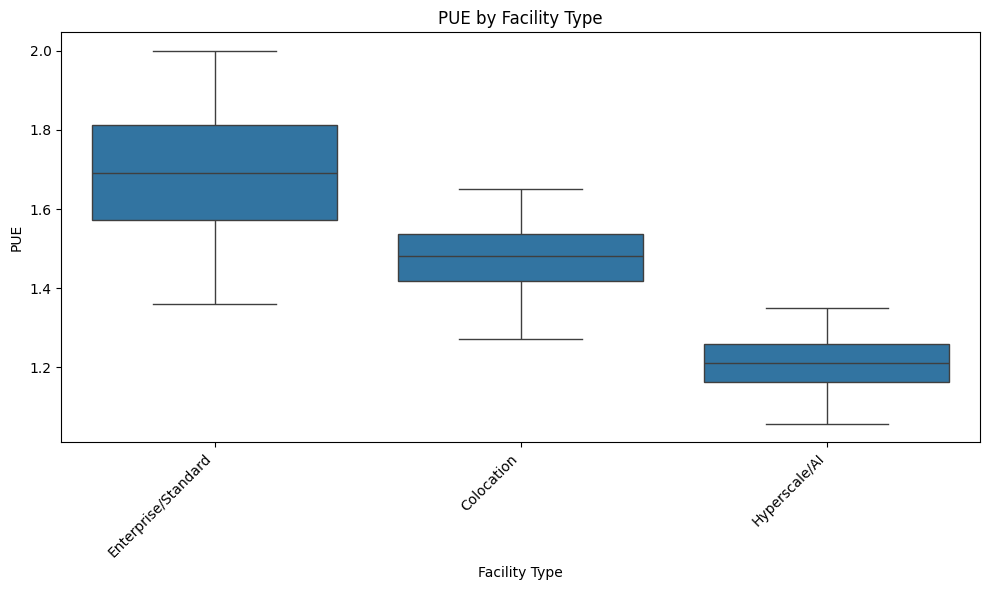

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Facility_Type', y='PUE')
plt.title('PUE by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

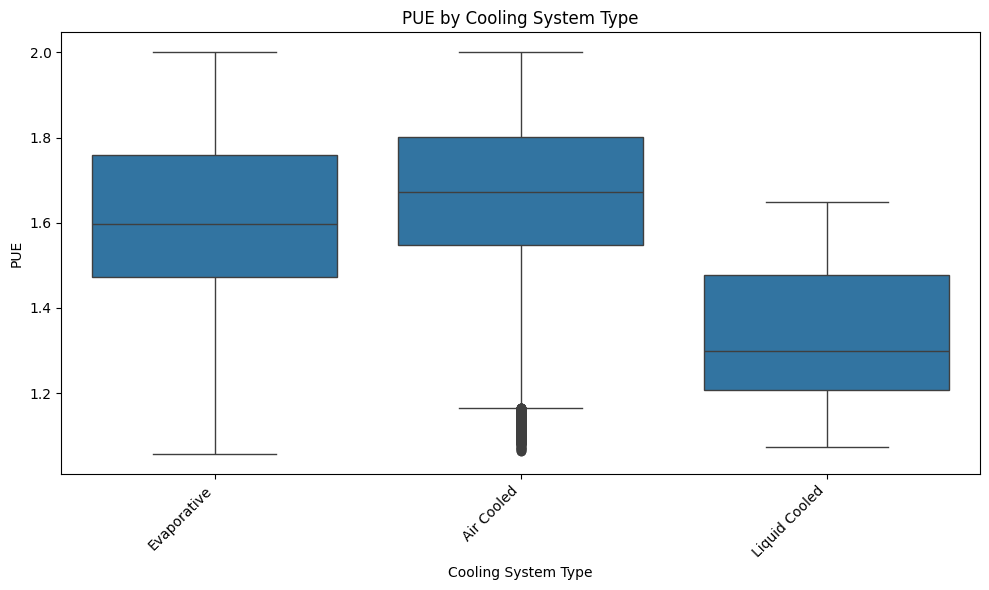

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cooling_System_Type', y='PUE')
plt.title('PUE by Cooling System Type')
plt.xlabel('Cooling System Type')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

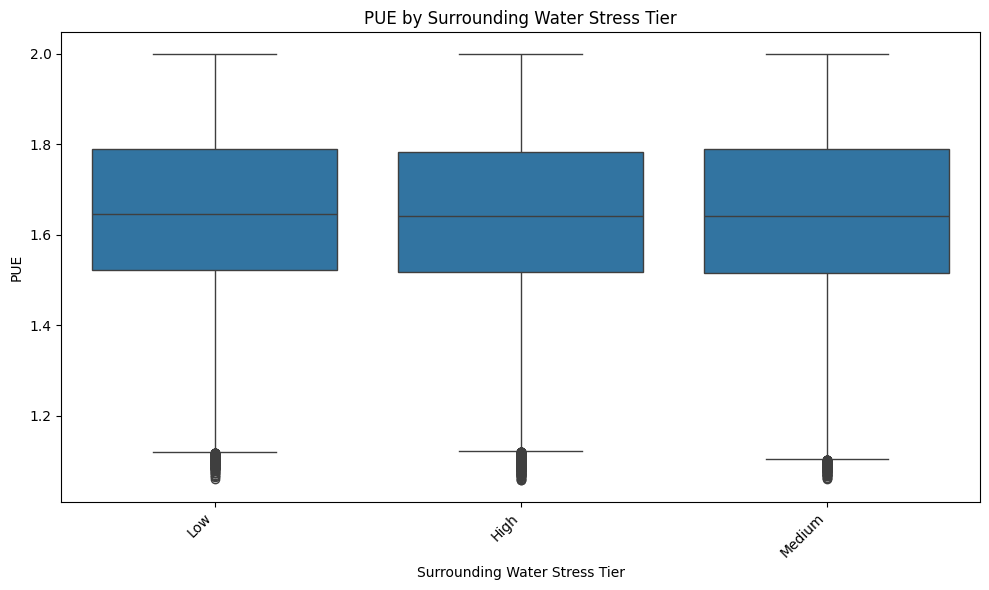

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Surrounding_Water_Stress_Tier', y='PUE')
plt.title('PUE by Surrounding Water Stress Tier')
plt.xlabel('Surrounding Water Stress Tier')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
mean_pue_by_owner = df.groupby('Owner_Company')['PUE'].mean().sort_values(ascending=False)
display(mean_pue_by_owner.head())

,PUE
Owner_Company,
Business Sviaz Holding,1.960000
Linkbynet,1.957286
Paratus Africa,1.950714
Pomorskie Centrum Przetwarzania Danych Sp. z o.o.,1.948857
POP-MG,1.948714


### Top 10 Companies by Mean PUE

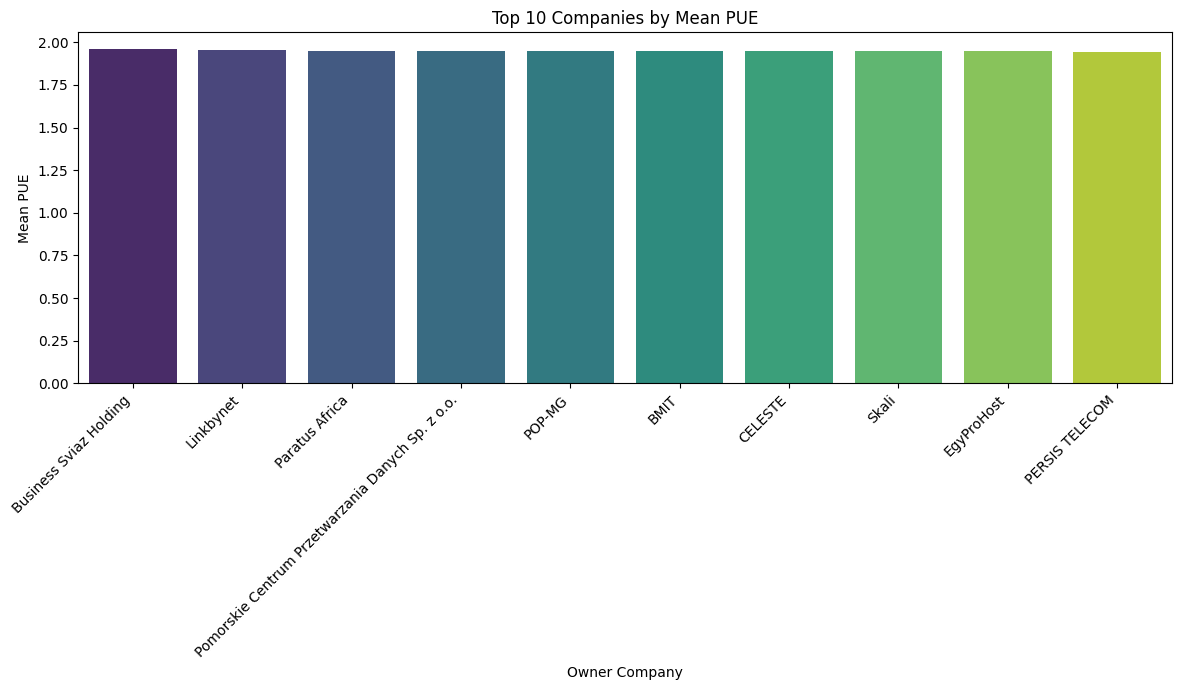

In [19]:
plt.figure(figsize=(12, 7))
sns.barplot(x=mean_pue_by_owner.head(10).index, y=mean_pue_by_owner.head(10).values, palette='viridis')
plt.title('Top 10 Companies by Mean PUE')
plt.xlabel('Owner Company')
plt.ylabel('Mean PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bottom 10 Companies by Mean PUE

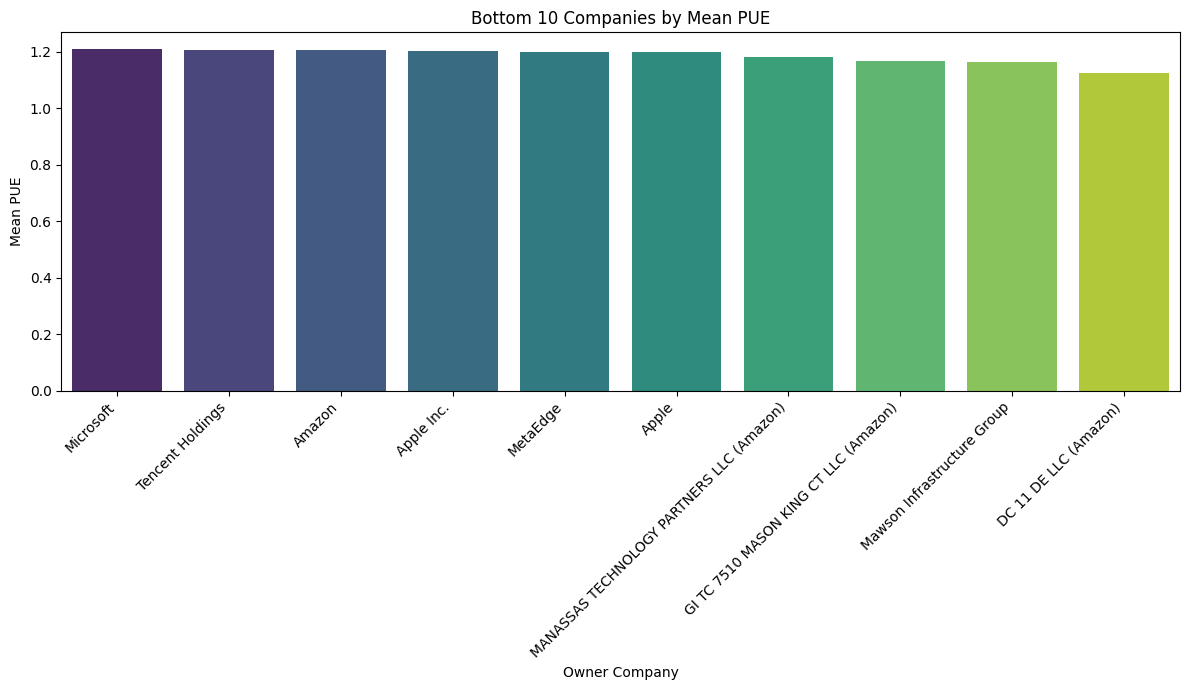

In [20]:
plt.figure(figsize=(12, 7))
sns.barplot(x=mean_pue_by_owner.tail(10).index, y=mean_pue_by_owner.tail(10).values, palette='viridis')
plt.title('Bottom 10 Companies by Mean PUE')
plt.xlabel('Owner Company')
plt.ylabel('Mean PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()